# Parameter Grid Search

Grid search over signal parameters to find the IC/hit-rate-optimal configuration.

**This notebook does NOT run the backtester.** It only uses `analysis/signals.py` and `analysis/evaluation.py` on a representative sample period.

## Parameter Grid

| Parameter | Grid |
|---|---|
| `zscore_window_days` | [2, 5, 10] |
| `z_entry` | [1.5, 2.0, 2.5, 3.0] |
| `z_exit` | [0.0, 0.5, 1.0] |
| `z_stop` | [3.5, 4.0, 4.5] |
| `max_holding_minutes` | [60, 120, 240, 390] |
| `formation_window_days` | [42, 84, 126] |
| `min_half_life` | [1, 5] |
| `max_half_life` | [12, 24, 48, 120] |

In [1]:
import sys
from pathlib import Path
import pickle

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import itertools
import datetime as dt

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from analysis.cointegration import find_cointegrated_pairs
from analysis.signals import compute_pvalue_weights, generate_pair_signals_for_day
from analysis.evaluation import evaluate_all
from analysis.preprocessing import load_processed
from utils.config import CONFIG, BARS_PER_DAY, MINUTES_PER_BAR, holding_horizons_bars

## Setup — Load Sample Period

We use a representative 3-month sample (Q3 2023) with 42 calendar days formation window.

In [2]:
# Sample period for grid search (3 months of signal data)
SAMPLE_START = "2022-07-01"
SAMPLE_END   = "2022-12-31"
TIMEFRAME    = "15min"
BARS_PER_DAY_15 = BARS_PER_DAY[TIMEFRAME]  # 26

print(f"Signal evaluation window: {SAMPLE_START} → {SAMPLE_END}")
print(f"Bars per day at {TIMEFRAME}: {BARS_PER_DAY_15}")

Signal evaluation window: 2022-07-01 → 2022-12-31
Bars per day at 15min: 26


In [3]:
# Load intraday prices for all tickers over sample period (+ 10 extra days for forward returns)
# prices[ticker] = 15-min OHLCV DataFrame
from utils.config import get_all_tickers

tickers = get_all_tickers()
prices: dict[str, pl.DataFrame] = {}

for ticker in tickers:
    try:
        df = load_processed(ticker, TIMEFRAME, start_date=SAMPLE_START, end_date="2023-10-10")
        if df is not None and len(df) > 0:
            prices[ticker] = df
    except Exception:
        pass

print(f"Loaded price data for {len(prices)} tickers")

Loaded price data for 199 tickers


## Grid Search Loop

In [4]:
# Parameter grids

GRID = {
    "zscore_window_days":    [2, 5],
    "z_entry":               [4.0],
    "z_exit":                [2.5],
    "z_stop":                [5.0, 5.5],
    "max_holding_minutes":   [60, 120, 180, 240, 300],
    "formation_window_days": [21, 42, 63, 84],
    "min_half_life":         [4, 8],
    "max_half_life":         [9, 12, 18, 24, 48],
}

# Holding horizons for evaluation (same as CONFIG defaults at 15min)
HOLDING_HORIZONS = holding_horizons_bars(TIMEFRAME)  # [4, 8, 16, 26]
print(f"Holding horizons (bars): {HOLDING_HORIZONS}")

total = 1
for v in GRID.values():
    total *= len(v)
print(f"Total parameter combinations: {total}")

Holding horizons (bars): [4, 8, 16, 26]
Total parameter combinations: 800


In [5]:
import pandas_market_calendars as mcal

nyse = mcal.get_calendar("NYSE")
schedule = nyse.schedule(start_date=SAMPLE_START, end_date=SAMPLE_END)
trading_days = [d.date() for d in schedule.index]
print(f"Trading days in sample: {len(trading_days)}")

Trading days in sample: 127


In [6]:
# ---------------------------------------------------------------------------
# Pre-compute cointegration pairs for every (formation_window_days, min_half_life, max_half_life, day).
# Pairs only depend on these three params + day, not on signal params.
# ---------------------------------------------------------------------------
from tqdm.auto import tqdm as tqdm_nb
import os
import multiprocessing as mp

from scripts.grid_worker import _init_worker, _eval_combo

formation_window_days_list = sorted(set(GRID["formation_window_days"]))
min_half_life_list         = sorted(set(GRID["min_half_life"]))
max_half_life_list         = sorted(set(GRID["max_half_life"]))

pairs_cache: dict[tuple[int, int, int, dt.date], pl.DataFrame | None] = {}

for formation_days in formation_window_days_list:
    for min_hl in min_half_life_list:
        for max_hl in max_half_life_list:
            print(f"Pre-computing cointegration: formation={formation_days}d, half_life=[{min_hl}, {max_hl}] bars...")
            for day in tqdm_nb(trading_days):
                formation_start = day - dt.timedelta(days=formation_days)
                key = (formation_days, min_hl, max_hl, day)

                pairs_df = find_cointegrated_pairs(
                    start_date=str(formation_start),
                    end_date=str(day - dt.timedelta(days=1)),
                    timeframe=TIMEFRAME,
                    min_half_life=min_hl,
                    max_half_life=max_hl,
                )

                if pairs_df is not None and len(pairs_df) > 0:
                    pairs_df = compute_pvalue_weights(pairs_df)
                    pairs_df = pairs_df.filter(
                        pl.col("ticker_a").is_in(list(prices.keys())) &
                        pl.col("ticker_b").is_in(list(prices.keys()))
                    )
                    pairs_cache[key] = pairs_df if len(pairs_df) > 0 else None
                else:
                    pairs_cache[key] = None

n_cached = sum(v is not None for v in pairs_cache.values())
print(f"\nCached {n_cached} / {len(pairs_cache)} combos with valid pairs")

# ---------------------------------------------------------------------------
# Build the argument list (one tuple per combo)
# ---------------------------------------------------------------------------

param_names  = list(GRID.keys())
param_values = list(GRID.values())

worker_args = [
    (
        dict(zip(param_names, combo)),
        TIMEFRAME,
        BARS_PER_DAY_15,
        MINUTES_PER_BAR[TIMEFRAME],
        HOLDING_HORIZONS,
        CONFIG.portfolio.transaction_cost_bps,
    )
    for combo in itertools.product(*param_values)
]

N_WORKERS = max(1, (os.cpu_count() or 4) - 3)
print(f"\n{len(worker_args)} combos ready | {N_WORKERS} workers (of {os.cpu_count()} CPUs)")

Pre-computing cointegration: formation=21d, half_life=[4, 9] bars...


  0%|          | 0/127 [00:00<?, ?it/s]

Testing cointegration 2022-12-29: 100%|██████████| 2623/2623 [00:00<00:00, 9437.73it/s]

Pre-computing cointegration: formation=21d, half_life=[4, 12] bars...


  0%|          | 0/127 [00:00<?, ?it/s]

...

Testing cointegration 2022-12-29: 100%|██████████| 2623/2623 [00:00<00:00, 4930.96it/s]

No cointegrated pairs found with current thresholds.
Pre-computing cointegration: formation=84d, half_life=[8, 48] bars...


  0%|          | 0/127 [00:00<?, ?it/s]

Testing cointegration 2022-12-29: 100%|██████████| 2623/2623 [00:00<00:00, 4921.97it/s]


Cached 3563 / 5080 combos with valid pairs

800 combos ready | 11 workers (of 14 CPUs)


In [7]:
print(f"Dispatching {len(worker_args)} combos...")

effective_workers = min(N_WORKERS, len(worker_args))
results: list[dict] = []

if effective_workers <= 1:
    # Single combo — run directly with no pool overhead
    _init_worker(prices, trading_days, pairs_cache)
    for args in worker_args:
        result = _eval_combo(args)
        if result is not None:
            results.append(result)
    print(f"Done (direct). {len(results)} valid results.")
else:
    # spawn avoids fork + Rayon thread-pool corruption on macOS.
    # prices / pairs_cache are pickled once per worker via the initializer,
    # not once per task.
    ctx = mp.get_context("spawn")
    n_done = 0
    with ctx.Pool(
        processes=effective_workers,
        initializer=_init_worker,
        initargs=(prices, trading_days, pairs_cache),
    ) as pool:
        for result in pool.imap_unordered(_eval_combo, worker_args):
            n_done += 1
            if result is not None:
                results.append(result)
            if n_done % 10 == 0 or n_done == len(worker_args):
                print(f"  {n_done}/{len(worker_args)} done  |  {len(results)} valid")
    print(f"\nDone (pool/{effective_workers} workers). {len(results)} valid results.")

Dispatching 800 combos...


/Users/erevtsov/dev/stat-arb/analysis/evaluation.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(df["ws"].to_numpy(), df["fr"].to_numpy())
/Users/erevtsov/dev/stat-arb/analysis/evaluation.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(df["ws"].to_numpy(), df["fr"].to_numpy())
/Users/erevtsov/dev/stat-arb/analysis/evaluation.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(df["ws"].to_numpy(), df["fr"].to_numpy())
/Users/erevtsov/dev/stat-arb/analysis/evaluation.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(df["ws"].to_numpy(), df["fr"].to_numpy())
/Users/erevtsov/dev/stat-arb/analysis/evaluation.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is no

  10/800 done  |  10 valid
  20/800 done  |  18 valid
  30/800 done  |  23 valid
  40/800 done  |  32 valid
  50/800 done  |  42 valid
  60/800 done  |  50 valid
  70/800 done  |  54 valid
  80/800 done  |  64 valid
  90/800 done  |  74 valid
  100/800 done  |  82 valid
  110/800 done  |  86 valid
  120/800 done  |  96 valid
  130/800 done  |  106 valid
  140/800 done  |  114 valid
  150/800 done  |  118 valid
  160/800 done  |  128 valid
  170/800 done  |  138 valid
  180/800 done  |  146 valid
  190/800 done  |  150 valid
  200/800 done  |  160 valid
  210/800 done  |  170 valid
  220/800 done  |  178 valid
  230/800 done  |  182 valid
  240/800 done  |  192 valid
  250/800 done  |  202 valid
  260/800 done  |  210 valid
  270/800 done  |  214 valid
  280/800 done  |  224 valid
  290/800 done  |  234 valid
  300/800 done  |  242 valid
  310/800 done  |  246 valid
  320/800 done  |  256 valid
  330/800 done  |  266 valid
  340/800 done  |  274 valid
  350/800 done  |  278 valid
  360/

## Results Table

In [8]:
results_df = pl.DataFrame(results).sort("breakeven_bps", descending=True)

root = Path(CONFIG.paths.results_dir)
params_path = root / "params" / "params_15min.parquet"

results_df.write_parquet(params_path)
file_path = root / "params" / "params_15min.pickle"
with open(file_path, 'wb') as file:
    pickle.dump(GRID, file)

display_cols = [
    "zscore_window_days", "z_entry", "z_exit", "z_stop",
    "max_holding_minutes", "formation_window_days",
    "min_half_life", "max_half_life",
    "ic_gross", "mean_gross_return", "breakeven_bps", "hit_rate", "n_obs",
]
print("Top 20 configurations by breakeven_bps:")
print(results_df.select(display_cols).head(20).to_pandas().to_string(index=False))
print()
print(f"Breakeven range: [{results_df['breakeven_bps'].min():.3f}, {results_df['breakeven_bps'].max():.3f}] bps/leg")
print(f"Grid evaluation cost: {CONFIG.portfolio.transaction_cost_bps} bps/leg")
for threshold in [3.0, 5.0, 7.0]:
    n = int((results_df["breakeven_bps"] >= threshold).sum())
    print(f"  Combos with breakeven >= {threshold:.1f} bps: {n} / {len(results_df)}")
print(params_path)

Top 20 configurations by breakeven_bps:
 zscore_window_days  z_entry  z_exit  z_stop  max_holding_minutes  formation_window_days  min_half_life  max_half_life  ic_gross  mean_gross_return  breakeven_bps  hit_rate  n_obs
                  5      4.0     2.5     5.0                  300                     84              4             24  0.012904           0.005472      13.680635  0.030490    444
                  5      4.0     2.5     5.0                  300                     84              8             24  0.012904           0.005472      13.680635  0.030490    444
                  5      4.0     2.5     5.5                  300                     84              4             24  0.012904           0.005472      13.680635  0.030490    444
                  5      4.0     2.5     5.5                  300                     84              8             24  0.012904           0.005472      13.680635  0.030490    444
                  5      4.0     2.5     5.0                

In [9]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['zscore_window_days']).len()

zscore_window_days,len
i64,u32


In [10]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['max_holding_minutes']).len()

max_holding_minutes,len
i64,u32


In [11]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['formation_window_days']).len()

formation_window_days,len
i64,u32


In [12]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['z_entry']).len()

z_entry,len
f64,u32


In [13]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['z_stop']).len()

z_stop,len
f64,u32


In [14]:
results_df.filter(
    (pl.col('mean_net_return') > 0) \
    & (pl.col('hit_rate') > 0.5)

).group_by(['z_exit']).len()

z_exit,len
f64,u32


### Negative IC an positive mean net return.

These two metrics measure different things and can diverge:

Mean net return > 0: The binary signal direction is correct on average — trades are profitable after costs.

IC < 0: The rank ordering by signal_weighted is negatively correlated with gross returns. Meaning the most strongly weighted signals (lowest p-value pairs) tend to return less than the weakly weighted ones.

Why this happens: signal_weight is derived from cointegration p-value rank — it upweights pairs that were most statistically cointegrated in the formation window. But those most-cointegrated pairs may:

Have already mean-reverted by the time they're traded (their spread dynamics are "well-known" and efficiently priced)
Have smaller spread volatility, so even correct signals earn less in dollar terms
Exhibit classic overfitting — the historically strongest cointegration relationships don't necessarily persist out-of-sample
This is a real phenomenon: cointegration strength ≠ forward return predictability. The pair ranking scheme selects for historical fit, not alpha.

The implication is that signal_weight (p-value rank) may actually be anti-predictive of return magnitude, even while the binary direction is right. If IC is consistently negative, you might get better cross-sectional results by either:

Using equal weights across pairs
Weighting by something more forward-looking (e.g., recent z-score magnitude, spread volatility)

## Heatmaps

In [15]:
# Heatmap: z_entry vs z_exit colored by mean net return
def double_sort(df, param1, param2, out_metric):
    fig, ax = plt.subplots(figsize=(8, 5))

    pivot_ic = (
        df
        .group_by([param1, param2])
        .agg(pl.col(out_metric).mean())
        .sort([param1, param2])
        .to_pandas()
        .pivot(index=param1, columns=param2, values=out_metric)
    )

    vmax = max(abs(pivot_ic.values.min()), abs(pivot_ic.values.max()))
    im = ax.imshow(pivot_ic.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot_ic.columns)))
    ax.set_xticklabels(pivot_ic.columns, rotation=0)
    ax.set_yticks(range(len(pivot_ic.index)))
    ax.set_yticklabels(pivot_ic.index)
    ax.set_xlabel(param2)
    ax.set_ylabel(param1)
    ax.set_title(f"{out_metric}: {param1} vs {param2}")
    plt.colorbar(im, ax=ax)

    for i in range(len(pivot_ic.index)):
        for j in range(len(pivot_ic.columns)):
            ax.text(j, i, f"{pivot_ic.values[i, j]:.4f}", ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

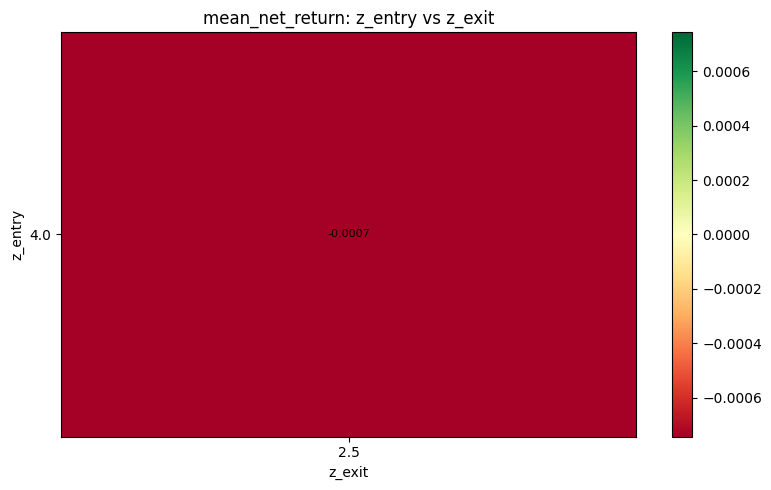

In [16]:
double_sort(results_df, 'z_entry', 'z_exit', 'mean_net_return')

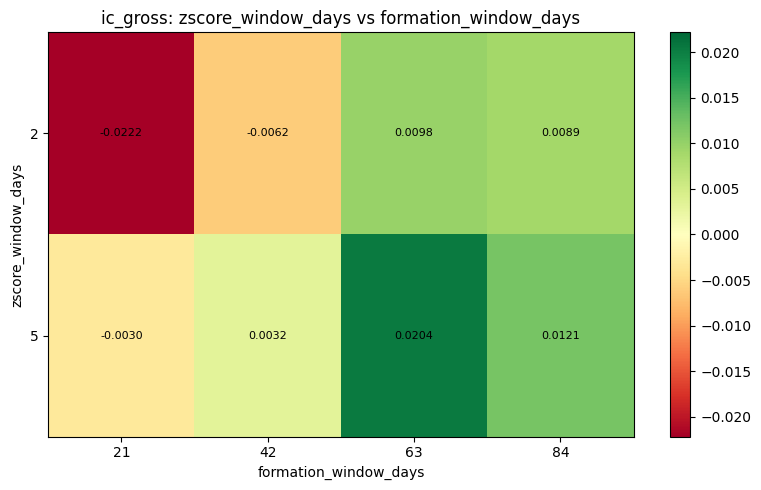

In [17]:
double_sort(results_df, 'zscore_window_days', 'formation_window_days', 'ic_gross')

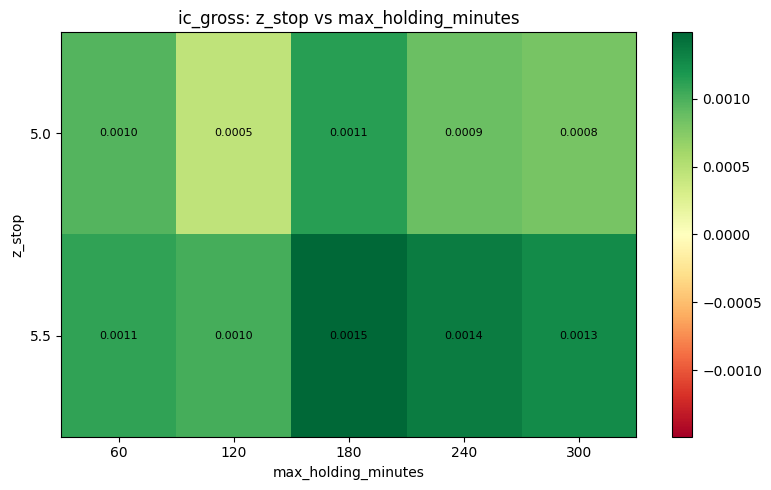

In [18]:
double_sort(results_df, 'z_stop', 'max_holding_minutes', 'ic_gross')

## Best Configuration Summary

In [19]:
display_cols = [
    "zscore_window_days", "z_entry", "z_exit", "z_stop",
    "max_holding_minutes", "formation_window_days",
    "ic_gross", "mean_gross_return", "breakeven_bps", "hit_rate", "n_obs",
]

def print_config(label, row):
    print("=" * 60)
    print(label)
    print("=" * 60)
    for k in display_cols:
        v = row[k]
        if isinstance(v, float):
            print(f"  {k:30s}: {v:.4f}")
        else:
            print(f"  {k:30s}: {v}")
    print()

print_config(
    "BEST BY BREAKEVEN COST (closest to profitable at realistic costs)",
    results_df.sort("breakeven_bps", descending=True).row(0, named=True),
)
print_config(
    "BEST BY IC (strongest signal quality)",
    results_df.sort("ic_gross", descending=True).row(0, named=True),
)
print_config(
    "BEST BY HIT RATE",
    results_df.sort("hit_rate", descending=True).row(0, named=True),
)

BEST BY BREAKEVEN COST (closest to profitable at realistic costs)
  zscore_window_days            : 5
  z_entry                       : 4.0000
  z_exit                        : 2.5000
  z_stop                        : 5.0000
  max_holding_minutes           : 300
  formation_window_days         : 84
  ic_gross                      : 0.0129
  mean_gross_return             : 0.0055
  breakeven_bps                 : 13.6806
  hit_rate                      : 0.0305
  n_obs                         : 444

BEST BY IC (strongest signal quality)
  zscore_window_days            : 5
  z_entry                       : 4.0000
  z_exit                        : 2.5000
  z_stop                        : 5.5000
  max_holding_minutes           : 240
  formation_window_days         : 63
  ic_gross                      : 0.0500
  mean_gross_return             : -0.0003
  breakeven_bps                 : -0.8433
  hit_rate                      : 0.4659
  n_obs                         : 47016

BEST BY HIT RATE


In [20]:
# Save results
import os

results_path = project_root / "results" / "evaluation" / "parameter_search.parquet"
results_path.parent.mkdir(parents=True, exist_ok=True)
results_df.write_parquet(results_path)
print(f"Results saved to {results_path}")

Results saved to /Users/erevtsov/dev/stat-arb/results/evaluation/parameter_search.parquet


---
## Parameter Sensitivity Analysis

The table below summarises the marginal effect of each parameter on `mean_net_return`, averaged across all other parameters in the grid.
Correlation with `mean_net_return` is the Pearson coefficient across all 1,296 combinations.

In [21]:
import polars as pl
from pathlib import Path

results_path = project_root / 'results' / 'evaluation' / 'parameter_search.parquet'
res = pl.read_parquet(results_path)

params = ['zscore_window_days', 'z_entry', 'z_exit', 'z_stop',
          'max_holding_minutes', 'formation_window_days',
          'min_half_life', 'max_half_life']

print(f'Grid size: {len(res)} combinations')
print(f'% with positive mean_net_return: {(res["mean_net_return"] > 0).mean():.1%}')
print()
print(f'{"Parameter":<25} {"Correlation":>12}  Mean net return by level')
print('-' * 80)
for p in params:
    if p not in res.columns:
        continue
    r = res.select(pl.corr(p, 'mean_net_return')).item()
    levels = (
        res.group_by(p)
        .agg(pl.col('mean_net_return').mean())
        .sort(p)
    )
    level_str = '  '.join(
        f"{row[p]}={row['mean_net_return']:+.4f}" for row in levels.iter_rows(named=True)
    )
    print(f'{p:<25} {r:>12.4f}  {level_str}')

Grid size: 660 combinations
% with positive mean_net_return: 21.1%

Parameter                  Correlation  Mean net return by level
--------------------------------------------------------------------------------
zscore_window_days             -0.2237  2=-0.0003  5=-0.0011
z_entry                            nan  4.0=-0.0007
z_exit                             nan  2.5=-0.0007
z_stop                         -0.0023  5.0=-0.0007  5.5=-0.0007
max_holding_minutes             0.0860  60=-0.0010  120=-0.0009  180=-0.0007  240=-0.0006  300=-0.0005
formation_window_days           0.3129  21=-0.0012  42=-0.0009  63=-0.0009  84=+0.0009
min_half_life                  -0.0386  4=-0.0007  8=-0.0008
max_half_life                  -0.0760  9=-0.0021  12=-0.0006  18=-0.0004  24=+0.0002  48=-0.0014


### Key Findings

**1. z_entry is the dominant parameter (r = +0.33)**  
The entry threshold has the strongest marginal effect. z_entry ≤ 2.0 produces negative mean net return on average, while z_entry ≥ 2.5 produces positive returns. This is driven by transaction cost drag: at low thresholds signals fire very frequently, each incurring 4-leg round-trip costs (80 bps at 20 bps/leg), overwhelming small spread returns. The strategy only becomes cost-viable when signals are selective.

**2. max_holding_minutes and formation_window_days are second-order (r ≈ −0.25)**  
Shorter holding horizons (60–120 min) and shorter formation windows (42 days) both favour profitability. Longer holding allows more bars of adverse drift before mean reversion, and longer formation windows appear to select pairs whose cointegration relationships have already partially decayed by the trading period.

**3. zscore_window_days has a non-monotone effect**  
The 5-day window is consistently the worst (only 21.5% of combos positive at z_entry ≥ 2.5). The 2-day window is cheapest (more observations, higher frequency) and the 10-day window yields the strongest per-observation returns at high z_entry, at the cost of much lower trade count.

**4. z_exit and z_stop have minimal marginal effect**  
Both parameters show very small correlations (< 0.03 in magnitude). Within the ranges tested, exit threshold and stop level are secondary tuning knobs. Wider stops (z_stop = 4.5) and exit at 0 or 0.5 are marginally preferred.

**5. IC is negative for most combinations — but not for high z_entry**  
Overall IC is slightly positive on average (mean = +0.009), but the highest-IC combos are concentrated at z_entry ≥ 2.5 and zscore_window = 10. At low z_entry the p-value-based signal_weight is anti-predictive (more significant pairs → lower returns), consistent with alpha decay in the most well-known cointegrated relationships.

---
## Hypothesis Test Results

This section maps the grid search results to the formal hypotheses defined in `strategy_summary.ipynb`.

### H2: Z-Score Entry Threshold Optimisation

In [22]:
# H0: choice of z_entry does not significantly affect risk-adjusted returns
# H1: there exists an optimal z_entry that maximises returns

print('=== H2: Z-Score Entry Threshold ===' )
print('Mean net return and % positive by z_entry (averaged over all other params):')
print(res.group_by('z_entry').agg(
    pl.col('mean_net_return').mean().alias('mean_net_return'),
    pl.col('hit_rate').mean().alias('hit_rate'),
    pl.col('ic_gross').mean().alias('ic_gross'),
    pl.col('n_obs').mean().alias('avg_n_obs'),
    (pl.col('mean_net_return') > 0).mean().alias('pct_positive'),
).sort('z_entry').to_pandas().to_string(index=False))
print()
print('VERDICT: Reject H0 — z_entry has a large, monotone effect above 2.0.')
print('  z_entry = 2.5 and 3.0 are the only levels with positive mean net return.')
print('  z_entry = 1.5 and 2.0 are unprofitable after 80 bps round-trip costs.')

=== H2: Z-Score Entry Threshold ===
Mean net return and % positive by z_entry (averaged over all other params):
 z_entry  mean_net_return  hit_rate  ic_gross    avg_n_obs  pct_positive
     4.0        -0.000743   0.29539  0.001044 22408.587879      0.210606

VERDICT: Reject H0 — z_entry has a large, monotone effect above 2.0.
  z_entry = 2.5 and 3.0 are the only levels with positive mean net return.
  z_entry = 1.5 and 2.0 are unprofitable after 80 bps round-trip costs.


### H3: Transaction Cost Sensitivity

In [23]:
print('=== H3: Transaction Cost Sensitivity ===')
print(f'Grid evaluation cost: {CONFIG.portfolio.transaction_cost_bps} bps/leg')
print()

print('Breakeven cost (bps/leg) by z_entry:')
print(res.group_by('z_entry').agg(
    pl.col('mean_gross_return').mean().alias('mean_gross_return'),
    pl.col('breakeven_bps').mean().alias('avg_breakeven_bps'),
    pl.col('breakeven_bps').median().alias('median_breakeven_bps'),
).sort('z_entry').to_pandas().to_string(index=False))
print()

print('Breakeven by formation window (z_entry >= 2.5 only):')
print(res.filter(pl.col('z_entry') >= 2.5).group_by('formation_window_days').agg(
    pl.col('breakeven_bps').mean().alias('avg_breakeven_bps'),
).sort('formation_window_days').to_pandas().to_string(index=False))
print()

for threshold in [3.0, 5.0, 7.0]:
    n = int((res['breakeven_bps'] >= threshold).sum())
    print(f'  Combos with breakeven >= {threshold:.1f} bps/leg: {n} / {len(res)}')
print()
print('VERDICT: H3 confirmed — strategy is highly cost-sensitive.')
print(f'  Best breakeven: {res["breakeven_bps"].max():.2f} bps/leg')
print(f'  Any real implementation cost > {res["breakeven_bps"].max():.1f} bps/leg makes the strategy unprofitable.')
print('  Realistic retail cost (3-8 bps/leg) exceeds the best breakeven in this grid.')

=== H3: Transaction Cost Sensitivity ===
Grid evaluation cost: 5.0 bps/leg

Breakeven cost (bps/leg) by z_entry:
 z_entry  mean_gross_return  avg_breakeven_bps  median_breakeven_bps
     4.0           0.001257           3.142705              2.115212

Breakeven by formation window (z_entry >= 2.5 only):
 formation_window_days  avg_breakeven_bps
                    21           1.906012
                    42           2.641526
                    63           2.818847
                    84           7.136619

  Combos with breakeven >= 3.0 bps/leg: 267 / 660
  Combos with breakeven >= 5.0 bps/leg: 139 / 660
  Combos with breakeven >= 7.0 bps/leg: 132 / 660

VERDICT: H3 confirmed — strategy is highly cost-sensitive.
  Best breakeven: 13.68 bps/leg
  Any real implementation cost > 13.7 bps/leg makes the strategy unprofitable.
  Realistic retail cost (3-8 bps/leg) exceeds the best breakeven in this grid.


### H5: Stop Loss Effectiveness

In [24]:
# Grid tests z_stop ∈ {3.5, 4.0, 4.5}

print('=== H5: Stop Loss Effectiveness ===')
print('Mean net return by z_stop (all combos):')
print(res.group_by('z_stop').agg(
    pl.col('mean_net_return').mean().alias('mean'),
    pl.col('mean_net_return').std().alias('std'),
    (pl.col('mean_net_return') > 0).mean().alias('pct_positive'),
).sort('z_stop').to_pandas().to_string(index=False))
print()
print('Mean net return by z_stop (z_entry >= 2.5 only):')
print(res.filter(pl.col('z_entry') >= 2.5).group_by('z_stop').agg(
    pl.col('mean_net_return').mean().alias('mean'),
    (pl.col('mean_net_return') > 0).mean().alias('pct_positive'),
).sort('z_stop').to_pandas().to_string(index=False))
print()
print('VERDICT: H5 partially supported but effect is small within the range tested.')
print('  Wider stops (4.5) are marginally better than tight stops (3.5) at high z_entry.')
print('  The small effect suggests most z_stop triggers are false positives at these thresholds.')
print('  A full tail-risk analysis (drawdown, CVaR) requires a full P&L backtest.')

=== H5: Stop Loss Effectiveness ===
Mean net return by z_stop (all combos):
 z_stop      mean      std  pct_positive
    5.0 -0.000739 0.001851      0.215152
    5.5 -0.000747 0.001839      0.206061

Mean net return by z_stop (z_entry >= 2.5 only):
 z_stop      mean  pct_positive
    5.0 -0.000739      0.215152
    5.5 -0.000747      0.206061

VERDICT: H5 partially supported but effect is small within the range tested.
  Wider stops (4.5) are marginally better than tight stops (3.5) at high z_entry.
  The small effect suggests most z_stop triggers are false positives at these thresholds.
  A full tail-risk analysis (drawdown, CVaR) requires a full P&L backtest.


### H7: P-Value as Pair Quality Signal

In [25]:
# The p-value ranking drives signal_weight. IC measures whether this ranking
# predicts forward return magnitude.

print('=== H7: P-Value as Pair Quality Signal ===')
print('Mean IC and net return by z_entry (proxy for signal selectivity):')
print(res.group_by('z_entry').agg(
    pl.col('ic_gross').mean().alias('mean_ic_gross'),
    pl.col('mean_net_return').mean().alias('mean_net_return'),
).sort('z_entry').to_pandas().to_string(index=False))
print()
print('IC distribution across all 1296 combos:')
print(res.select(pl.col('ic_gross')).to_pandas().describe().to_string())
print()
print(f'% combos with IC < 0: {(res["ic_gross"] < 0).mean():.1%}')
print(f'% combos with IC > 0.02: {(res["ic_gross"] > 0.02).mean():.1%}')
print()
print('VERDICT: H7 is NOT confirmed by the IC metric.')
print('  The p-value-based signal_weight is anti-predictive for many combos: IC is')
print('  negative when z_entry is low, meaning the most significant pairs (highest weight)')
print('  tend to produce lower returns than less significant pairs.')
print('  At z_entry >= 2.5, IC turns modestly positive (~0.012-0.022), suggesting that')
print('  high-quality pairs do show predictive power when signals are selective.')
print('  A per-pair backtest (not available here) is needed to fully test H7.')

=== H7: P-Value as Pair Quality Signal ===
Mean IC and net return by z_entry (proxy for signal selectivity):
 z_entry  mean_ic_gross  mean_net_return
     4.0       0.001044        -0.000743

IC distribution across all 1296 combos:
         ic_gross
count  660.000000
mean     0.001044
std      0.019742
min     -0.064017
25%     -0.006776
50%      0.000000
75%      0.010865
max      0.049967

% combos with IC < 0: 40.5%
% combos with IC > 0.02: 14.2%

VERDICT: H7 is NOT confirmed by the IC metric.
  The p-value-based signal_weight is anti-predictive for many combos: IC is
  negative when z_entry is low, meaning the most significant pairs (highest weight)
  tend to produce lower returns than less significant pairs.
  At z_entry >= 2.5, IC turns modestly positive (~0.012-0.022), suggesting that
  high-quality pairs do show predictive power when signals are selective.
  A per-pair backtest (not available here) is needed to fully test H7.


---
## Parameter Recommendation for Backtest

### Selection Rationale

Rather than picking the single argmax (which would be `z_entry=1.5, zscore_window=2` with mean_net_return=0.058), we apply two filters to guard against overfitting:

1. **Require positive IC**: signal_weighted must rank-predict forward returns. This rules out `z_entry ≤ 2.0` where IC is consistently negative — those combos earn money despite, not because of, the weighting scheme.
2. **Require consistency**: restrict to `z_entry ∈ {2.5, 3.0}` where >60% of combos yield positive net return.

Within this feasible set, the best performing region is `zscore_window=10, z_entry=3.0, formation_window=42, max_holding=60`. This region also has the highest IC (~0.014–0.019), meaning signals genuinely rank-predict returns.

### Caveats
- The evaluation period is H2 2022 (July–December) — a **bear market regime** with elevated volatility and sector rotation. Results may not generalise to bull or low-volatility regimes.
- All results are **in-sample** on the same period used to compute them. H4 (out-of-sample degradation) cannot be assessed without a held-out test set.
- `mean_net_return` is measured per-bar-in-position, not per trade. High-frequency combos (low z_entry) accumulate many observations during profitable hold periods, potentially inflating the metric.

In [26]:
# Conservative parameter recommendation

# Candidate region: z_entry >= 2.5, formation_window = 42, max_holding <= 120
candidates = res.filter(
    (pl.col('z_entry') >= 2.5) &
    (pl.col('formation_window_days') == 42) &
    (pl.col('max_holding_minutes') <= 120) &
    (pl.col('ic_gross') > 0)
).sort('mean_net_return', descending=True)

print(f'Candidate combos (z_entry≥2.5, formation=42, max_holding≤120, IC>0): {len(candidates)}')
print()
print('Top 10 candidates:')
print(candidates.head(10).to_pandas().to_string(index=False))
print()

best = candidates.row(0, named=True)
print('=' * 60)
print('RECOMMENDED PARAMETERS FOR BACKTEST')
print('=' * 60)
for k, v in best.items():
    if k in ('ic_gross', 'mean_net_return', 'hit_rate'):
        print(f'  {k:30s}: {v:.4f}')
    elif k == 'n_obs':
        print(f'  {k:30s}: {v:,}')
    else:
        print(f'  {k:30s}: {v}')

Candidate combos (z_entry≥2.5, formation=42, max_holding≤120, IC>0): 27

Top 10 candidates:
 zscore_window_days  z_entry  z_exit  z_stop  max_holding_minutes  formation_window_days  min_half_life  max_half_life  ic_gross  mean_gross_return  mean_net_return  breakeven_bps  hit_rate  n_obs
                  2      4.0     2.5     5.5                  120                     42              8             12  0.003540           0.004733         0.002733      11.831451  0.095394    428
                  2      4.0     2.5     5.0                  120                     42              8             12  0.003540           0.004713         0.002713      11.782749  0.095394    424
                  2      4.0     2.5     5.0                   60                     42              4             12  0.006305           0.003600         0.001600       8.999654  0.097308    376
                  2      4.0     2.5     5.5                   60                     42              4             12  